In [15]:
import os
import json
import networkx as nx
import matplotlib.pyplot as plt

In [16]:
files = "./logs-backup-20250803-123416"

In [17]:
def create_node_graph_dict(directory):
    node_id_to_name = {}
    node_graph = {}
    node_cnt = 0
    for filename in os.listdir(directory):
        filepath = os.path.join(directory, filename)
        if not os.path.isfile(filepath):
            continue
        with open(filepath, 'r', encoding='utf-8') as f:
            for line in f:
                if 'List of neighbors' in line:
                    d = json.loads(line)
                    node_graph[d['node_id']] = d.get('neighbors', [])
                    if d['node_id'] not in node_id_to_name:
                        node_id_to_name[d['node_id']] = f"node_{node_cnt}"
                        node_cnt += 1

    return node_id_to_name, node_graph

In [18]:
def build_directed_graph(node_names, graph):
    """
    Scans all files in `directory`, extracts nodes and neighbors, and builds a NetworkX DiGraph.
    """

    G = nx.DiGraph()

    for node, neighbors in graph.items():
        node_name = node_names[node]  
        G.add_node(node_name)
        for nbr in neighbors:
            if nbr in node_names:
                nbr_name = node_names[nbr]
            else:
                nbr_name = nbr
            G.add_node(nbr_name)
            G.add_edge(node_name, nbr_name)

    return G

In [19]:
def visualize_directed_graph(G, figsize=(12, 12), with_labels=True):
    # Project to undirected for consistent layout
    pos = nx.spring_layout(G, seed=42)
    plt.figure(figsize=figsize)

    # Separate edges by reciprocity
    solid_edges = []  # bidirectional
    dashed_edges = []  # one-way
    for u, v in G.edges():
        if G.has_edge(v, u):
            # ensure each is drawn only once
            if (v, u) not in solid_edges:
                solid_edges.append((u, v))
        else:
            dashed_edges.append((u, v))

    # Draw nodes and labels
    nx.draw_networkx_nodes(G, pos, node_size=300)
    if with_labels:
        nx.draw_networkx_labels(G, pos)

    # Draw bidirectional edges as solid undirected
    if solid_edges:
        nx.draw_networkx_edges(
            G.to_undirected(), pos,
            edgelist=solid_edges,
            style='solid',
            arrows=False
        )
    # Draw one-way edges as dashed with arrows
    if dashed_edges:
        nx.draw_networkx_edges(
            G, pos,
            edgelist=dashed_edges,
            style='dashed',
            arrows=True
        )

    plt.title("Directed Neighbor Graph (one-way edges dashed)")
    plt.axis('off')
    plt.show()

In [20]:
nodes, graph = create_node_graph_dict(files)

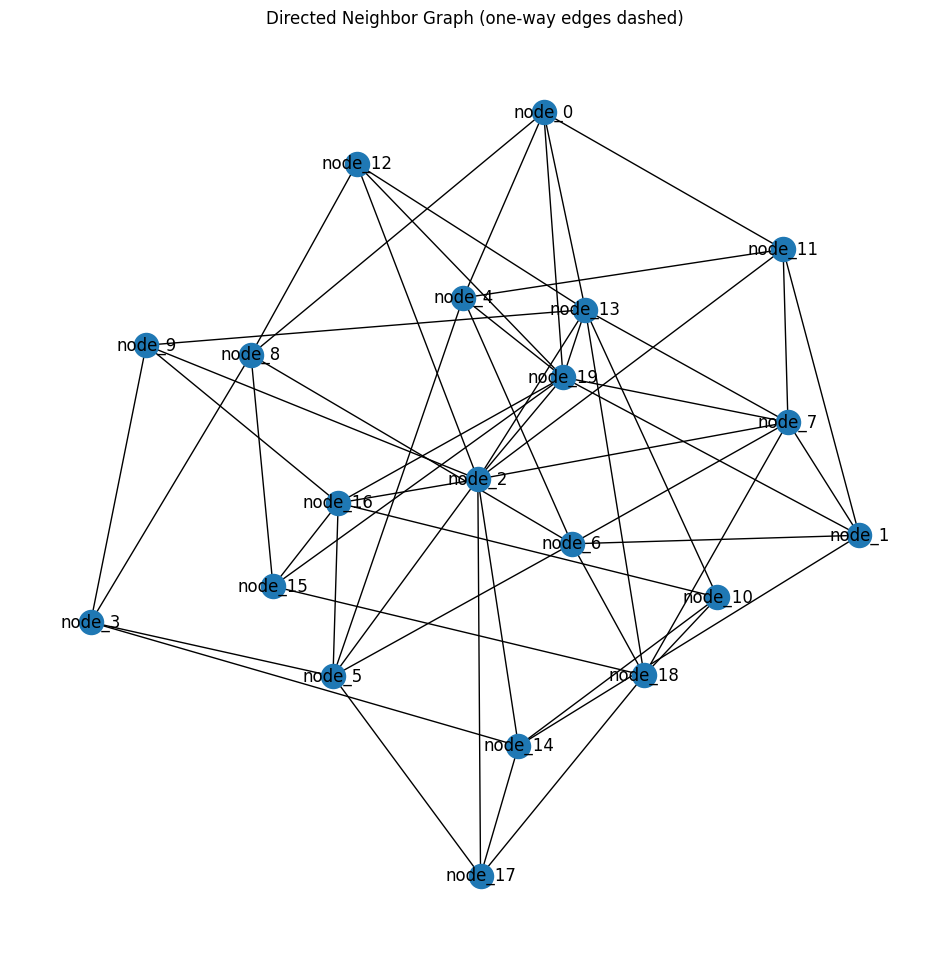

Number of connected components: 1
Component 1 (size 20): {'node_12', 'node_3', 'node_0', 'node_11', 'node_15', 'node_1', 'node_16', 'node_13', 'node_14', 'node_19', 'node_2', 'node_6', 'node_7', 'node_18', 'node_4', 'node_17', 'node_8', 'node_5', 'node_10', 'node_9'}
Diameter of component 1: 3


In [21]:
nodes, graph = create_node_graph_dict(files)
G = build_directed_graph(nodes, graph)

# Visualize directed graph
visualize_directed_graph(G)

# Analyze undirected projection for components and diameter
U = G.to_undirected()
comps = list(nx.connected_components(U))
print(f"Number of connected components: {len(comps)}")
for i, comp in enumerate(comps, 1):
    print(f"Component {i} (size {len(comp)}): {comp}")

for i, comp in enumerate(comps, 1):
    if len(comp) > 1:
        subU = U.subgraph(comp)
        diam = nx.diameter(subU)
        print(f"Diameter of component {i}: {diam}")
    else:
        print(f"Component {i} has a single node; diameter undefined.")

In [22]:
def analyze_committee(directory):
    all_committees = {}
    for filename in os.listdir(directory):
        filepath = os.path.join(directory, filename)
        if not os.path.isfile(filepath):
            continue
        with open(filepath, 'r', encoding='utf-8') as f:
            for line in f:
                if "Committee elected" in line:
                    d = json.loads(line)
                    node_id = d["node_id"]  
                    committee = d["committee"]
                    all_committees[node_id] = [id["ID"] for id in committee]
    return all_committees

In [23]:
member_to_nodes = analyze_committee(files)

In [25]:
committee = set()
for k, v in member_to_nodes.items():
    print(k, len(v))
    for c in v:
        committee.add(c)

print(len(committee))

12D3KooWJ9Vm9a95KycwybHsCq1eo4nxcaiyF4bFWvUo5GJBWnfv 10
12D3KooWQEqqLtzb9ttjjGtzGL9eicPymdLxoEM317ycvV1zwKVT 10
12D3KooWB2uDRpgFEjhiwtmxfJiZLdn5vFqxkCM1Lx23qgoLVfsT 10
12D3KooWGmAydDct7j5upDMsAPpMRHrCWsxybx1rbBxMCahtCfRu 10
12D3KooWDNVWt7QD9ykEWJkF1gy2k5ZXv4kx5pFNmfyZQrDCdZpY 10
12D3KooWGeGzzkJGFpLSDD41XsYQHJm9cJ2WoSt8fvpdRTCkrgCc 10
12D3KooWJsRhvaWXqXx5GsDrTajCno6D7SHSSe5KaTjcZY5gKn8p 10
12D3KooWJqsj4CfFAsYt6SscXAUtqnch4x32tqH3p1GR89Fmjk9r 10
12D3KooWNzTvimaXUBbV13hptY6rQ7pSMk3FkAjGwt9sjSYf262p 10
12D3KooWALeDG5XLeLERFQqB8CcDZwE9MMoeenXFjNcnfwwpfebv 10
12D3KooWDoaTmJ3D66Fgz77S9zpop3xWoTafdxTrEAyaP7poMLgW 10
12D3KooWHSrmrz5mRTsoWwhES2XFm4oUYr2LLc5Fbg5jvuZ9sLx7 10
12D3KooWH1fqiXdi4ZpEQztUSpdqt1RA9KZ3Ub48fbb5SEidNQeP 10
12D3KooWBc9JwzVB7m7BN7KdeRFXgEewnzyBtrAineYFn2cD154K 10
12D3KooWJVTRJ4zUi1AEw3LJZzs38waezNExU1JRqY4ZcopXxS4A 10
12D3KooWRYyiqDhkMUEibZFwSwuoq3fRpFmjoWywj7jjfaiKnMQg 10
12D3KooWSXtiN9kRpHW8FrTyJG47MXvWU217MrEdCGEGsAi2gemg 10
12D3KooWFbNj2zF6PRnnXCLEgyDYUJvgs5C7ukwQxnP3LnDo